# GariQeemat — Exploratory Data Analysis

**Goal:** Understand the PakWheels used-car dataset, clean it, and produce a tidy dataset for feature engineering.

**Dataset:** PakWheels Cars Data (ML/DL Ready) (https://www.kaggle.com/datasets/asarli/pakwheels-cars-data-mldl-ready-python-scraped) — Kaggle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RAW_PATH = '../data/raw/'
PROCESSED_PATH = '../data/processed/cleaned_data.csv'

## 1. Load & Initial Inspection

In [2]:
cars_data = pd.read_csv(RAW_PATH + "pak_wheel.csv")
cars_data

,Link,Car Name,Price,City,Registered In,Mileage,Fuel Type,Engine,Transmission
0,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 1984 DX for Sale,PKR 9lacs,Islamabad,1984,"125,000 km",Petrol,1300 cc,Manual
1,https://www.pakwheels.com/used-cars/search/-/c...,Suzuki Swift 2019 DLX 1.3 Navigation for Sale,PKR 28.25lacs,Lahore,2019,"57,000 km",Petrol,1300 cc,Manual
2,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 2016 GLi 1.3 VVTi for Sale6.4/10,PKR 41lacs,Islamabad,2016,"124,467 km",Petrol,1300 cc,Manual
3,https://www.pakwheels.com/used-cars/search/-/c...,Honda City 5th (GM2) Generation 2016 1.3 i-VTE...,PKR 31.95lacs,Islamabad,2016,"251,378 km",Petrol,1300 cc,Manual
4,https://www.pakwheels.com/used-cars/search/-/c...,Suzuki Swift 2015 DLX Automatic 1.3 for Sale,PKR 23.75lacs,Karachi,2015,"52,000 km",Petrol,1300 cc,Automatic
...,...,...,...,...,...,...,...,...,...
5767,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 2007 XLi for Sale,PKR 15.65lacs,Karachi,2007,"104,500 km",Petrol,1300 cc,Manual
5768,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Crown 1984 for Sale,PKR 12.5lacs,Karachi,1984,"12,222 km",Petrol,1300 cc,Manual
5769,https://www.pakwheels.com/used-cars/search/-/c...,Suzuki Cultus 2006 for Sale,PKR 11lacs,Karachi,2006,"10,000 km",Petrol,1300 cc,Automatic
5770,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 1999 XE-G for Sale,PKR 10.9lacs,Karachi,1999,"135,000 km",Petrol,1300 cc,Manual


## 2. Display Top-5 rows

In [3]:
cars_data.head()

,Link,Car Name,Price,City,Registered In,Mileage,Fuel Type,Engine,Transmission
0,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 1984 DX for Sale,PKR 9lacs,Islamabad,1984,"125,000 km",Petrol,1300 cc,Manual
1,https://www.pakwheels.com/used-cars/search/-/c...,Suzuki Swift 2019 DLX 1.3 Navigation for Sale,PKR 28.25lacs,Lahore,2019,"57,000 km",Petrol,1300 cc,Manual
2,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 2016 GLi 1.3 VVTi for Sale6.4/10,PKR 41lacs,Islamabad,2016,"124,467 km",Petrol,1300 cc,Manual
3,https://www.pakwheels.com/used-cars/search/-/c...,Honda City 5th (GM2) Generation 2016 1.3 i-VTE...,PKR 31.95lacs,Islamabad,2016,"251,378 km",Petrol,1300 cc,Manual
4,https://www.pakwheels.com/used-cars/search/-/c...,Suzuki Swift 2015 DLX Automatic 1.3 for Sale,PKR 23.75lacs,Karachi,2015,"52,000 km",Petrol,1300 cc,Automatic


## 3. Display Bottom-5 rows

In [4]:
cars_data.tail()

,Link,Car Name,Price,City,Registered In,Mileage,Fuel Type,Engine,Transmission
5767,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 2007 XLi for Sale,PKR 15.65lacs,Karachi,2007,"104,500 km",Petrol,1300 cc,Manual
5768,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Crown 1984 for Sale,PKR 12.5lacs,Karachi,1984,"12,222 km",Petrol,1300 cc,Manual
5769,https://www.pakwheels.com/used-cars/search/-/c...,Suzuki Cultus 2006 for Sale,PKR 11lacs,Karachi,2006,"10,000 km",Petrol,1300 cc,Automatic
5770,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 1999 XE-G for Sale,PKR 10.9lacs,Karachi,1999,"135,000 km",Petrol,1300 cc,Manual
5771,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Starlet 1984 1.3 for Sale,PKR 6.5lacs,Karachi,1984,"1,230 km",Petrol,1300 cc,Manual


## 4. Checking the shape of the data

In [5]:
overall_shape = cars_data.shape
print(f"Overall shape (rows + cols): {overall_shape}")
print(f"No.of rows: {overall_shape[0]}")
print(f"No.of cols: {overall_shape[1]}")

Overall shape (rows + cols): (5772, 9)
No.of rows: 5772
No.of cols: 9


## 5. Get the overall information about the dataset

In [6]:
cars_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5772 entries, 0 to 5771
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Link           5772 non-null   str  
 1   Car Name       5772 non-null   str  
 2   Price          5772 non-null   str  
 3   City           5772 non-null   str  
 4   Registered In  5772 non-null   int64
 5   Mileage        5772 non-null   str  
 6   Fuel Type      5772 non-null   str  
 7   Engine         5772 non-null   str  
 8   Transmission   5772 non-null   str  
dtypes: int64(1), str(8)
memory usage: 1.4 MB


## 6. Check the overall statistics of data

In [7]:
cars_data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Link,5772,209,https://www.pakwheels.com/used-cars/search/-/c...,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car Name,5772,930,Toyota Yaris Sedan 2025 GLI CVT 1.3 for Sale,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,5772,787,PKR 22.5lacs,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,5772,3,Lahore,2146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Registered In,5772.0,NaN,NaN,NaN,2011.163895,8.35884,1966.0,2006.0,2012.0,2017.0,2025.0
Mileage,5772,1275,"100,000 km",273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,5772,5,Petrol,5642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine,5772,6,1300 cc,5716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,5772,2,Manual,3904,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Identify the missing values

In [8]:
cars_data.isnull().sum()

Link             0
Car Name         0
Price            0
City             0
Registered In    0
Mileage          0
Fuel Type        0
Engine           0
Transmission     0
dtype: int64

## 8. Idenftifying Duplicate values

In [9]:
cars_data.duplicated().sum()

np.int64(6)

#### Dropping duplicate rows

In [10]:
print(f"Shape before dropping duplicate rows: {overall_shape}")
cars_data = cars_data.drop_duplicates()
print(f"Shape after dropping duplicate rows: {cars_data.shape}")
print(f"Total rows dropped: {overall_shape[0] - cars_data.shape[0]}")

Shape before dropping duplicate rows: (5772, 9)
Shape after dropping duplicate rows: (5766, 9)
Total rows dropped: 6


---
## 9. Data Cleaning — Fixing Column Types

Right now `Price`, `Mileage`, and `Engine` are stored as messy strings (e.g. `"PKR 28.25lacs"`, `"57,000 km"`, `"1300 cc"`). `Car Name` bundles the brand, model, year, and trim together, and some rows even have a rating like `6.4/10` glued onto `"for Sale"`. We'll parse all of this into clean, numeric/categorical columns before we can visualize or model anything.

In [11]:
import re

def parse_price(value):
    """Convert 'PKR 28.25lacs' / 'PKR 1.2crore' style strings into a plain PKR float."""
    text = str(value).replace(',', '').strip()
    match = re.search(r'PKR\s*([\d.]+)\s*(crore|lacs|lac|thousand)?', text, re.IGNORECASE)
    if not match:
        return np.nan
    amount = float(match.group(1))
    unit = (match.group(2) or '').lower()
    multiplier = {'crore': 1e7, 'lacs': 1e5, 'lac': 1e5, 'thousand': 1e3, '': 1}
    return amount * multiplier.get(unit, 1)

def parse_mileage(value):
    """Convert '125,000 km' -> 125000 (int)."""
    text = str(value).replace(',', '').lower().replace('km', '').strip()
    try:
        return int(float(text))
    except ValueError:
        return np.nan

def parse_engine(value):
    """Convert '1300 cc' -> 1300 (int)."""
    text = str(value).lower().replace('cc', '').strip()
    try:
        return int(float(text))
    except ValueError:
        return np.nan

def parse_car_name(value):
    """Split 'Toyota Corolla  2016 GLi 1.3 VVTi for Sale6.4/10' into Brand/Model/Variant."""
    text = str(value)
    # remove a rating glued onto 'for Sale' e.g. 'for Sale6.4/10'
    text = re.sub(r'for Sale\s*\d+(\.\d+)?/10', 'for Sale', text)
    # drop the trailing 'for Sale' marketing text
    text = re.sub(r'\s*for Sale\s*$', '', text, flags=re.IGNORECASE).strip()
    year_match = re.search(r'\b(19|20)\d{2}\b', text)
    if year_match:
        before, after = text[:year_match.start()].strip(), text[year_match.end():].strip()
    else:
        before, after = text, ''
    parts = before.split()
    brand = parts[0] if len(parts) > 0 else np.nan
    model = parts[1] if len(parts) > 1 else np.nan
    variant = (' '.join(parts[2:]) + ' ' + after).strip()
    return pd.Series([brand, model, variant if variant else np.nan])

print('Parsing functions ready.')

Parsing functions ready.


In [12]:
cars_data['Price_PKR'] = cars_data['Price'].apply(parse_price)
cars_data['Mileage_km'] = cars_data['Mileage'].apply(parse_mileage)
cars_data['Engine_cc'] = cars_data['Engine'].apply(parse_engine)
cars_data[['Brand', 'Model', 'Variant']] = cars_data['Car Name'].apply(parse_car_name)
cars_data = cars_data.rename(columns={'Registered In': 'Year'})

CURRENT_YEAR = 2026
cars_data['Car_Age'] = CURRENT_YEAR - cars_data['Year']

# Drop columns we no longer need for modeling
cars_data = cars_data.drop(columns=['Link', 'Car Name', 'Price', 'Mileage', 'Engine'])

cars_data.head()

,City,Year,Fuel Type,Transmission,Price_PKR,Mileage_km,Engine_cc,Brand,Model,Variant,Car_Age
0,Islamabad,1984,Petrol,Manual,900000.0,125000,1300.0,Toyota,Corolla,DX,42
1,Lahore,2019,Petrol,Manual,2825000.0,57000,1300.0,Suzuki,Swift,DLX 1.3 Navigation,7
2,Islamabad,2016,Petrol,Manual,4100000.0,124467,1300.0,Toyota,Corolla,GLi 1.3 VVTi,10
3,Islamabad,2016,Petrol,Manual,3195000.0,251378,1300.0,Honda,City,5th (GM2) Generation 1.3 i-VTEC,10
4,Karachi,2015,Petrol,Automatic,2375000.0,52000,1300.0,Suzuki,Swift,DLX Automatic 1.3,11


In [13]:
print('New dtypes after cleaning:')
print(cars_data.dtypes)
print()
print('Nulls introduced by parsing (should be near 0):')
print(cars_data[['Price_PKR', 'Mileage_km', 'Engine_cc', 'Brand', 'Model', 'Year']].isnull().sum())

New dtypes after cleaning:
City                str
Year              int64
Fuel Type           str
Transmission        str
Price_PKR       float64
Mileage_km        int64
Engine_cc       float64
Brand               str
Model               str
Variant             str
Car_Age           int64
dtype: object

Nulls introduced by parsing (should be near 0):
Price_PKR     16
Mileage_km     0
Engine_cc      3
Brand          0
Model          0
Year           0
dtype: int64


In [14]:
bad_price_rows = cars_data[cars_data['Price_PKR'].isnull()]
if len(bad_price_rows):
    print(f"{len(bad_price_rows)} rows have an unparsed Price — inspect and patch the regex/fill manually:")
    display(bad_price_rows)
else:
    print('All Price values parsed successfully.')

16 rows have an unparsed Price — inspect and patch the regex/fill manually:


,City,Year,Fuel Type,Transmission,Price_PKR,Mileage_km,Engine_cc,Brand,Model,Variant,Car_Age
1069,Lahore,2025,Petrol,Automatic,NaN,25,1300.0,Toyota,Yaris,Sedan GLI CVT 1.3,1
1619,Lahore,2025,Petrol,Automatic,NaN,50,1300.0,Toyota,Yaris,Sedan GLI CVT 1.3,1
1628,Islamabad,2020,Petrol,Automatic,NaN,28000,1300.0,Mercedes,Benz,A Class A200,6
1645,Lahore,2025,Petrol,Automatic,NaN,25,1300.0,Toyota,Yaris,Sedan GLI CVT 1.3,1
1699,Islamabad,2025,Petrol,Automatic,NaN,20,1300.0,Toyota,Yaris,Sedan GLI CVT 1.3,1
1768,Karachi,2025,Petrol,Automatic,NaN,51,1300.0,Toyota,Yaris,Sedan GLI CVT 1.3,1
1775,Islamabad,2025,Petrol,Automatic,NaN,20,1300.0,Toyota,Yaris,Sedan GLI CVT 1.3,1
1776,Islamabad,2025,Petrol,Automatic,NaN,5,1300.0,Toyota,Yaris,Sedan GLI CVT 1.3,1
2953,Lahore,2025,Petrol,Automatic,NaN,50,1300.0,Toyota,Yaris,Sedan GLI CVT 1.3,1
3067,Islamabad,2020,Petrol,Automatic,NaN,28000,1300.0,Mercedes,Benz,A Class A200,6


#### Dropping `NaN`rows

In [15]:
# Drop rows where price is NaN
print(f"Shape before dropping: {cars_data.shape}")
cars_data = cars_data.dropna(subset=['Price_PKR'])

# Also drop any zero or negative prices
cars_data = cars_data[cars_data['Price_PKR'] > 0]

print(f"Cleaned shape: {cars_data.shape}")

Shape before dropping: (5766, 11)
Cleaned shape: (5750, 11)


### Sanity-check the numeric ranges

Used-car prices, mileage, and registration years can hide data-entry errors (e.g. a car "registered" in 1900, or a price of PKR 0). Let's check the min/max before we trust the columns.

In [16]:
cars_data[['Price_PKR', 'Mileage_km', 'Engine_cc', 'Year', 'Car_Age']].describe().T

,count,mean,std,min,25%,50%,75%,max
Price_PKR,5750.0,2.658208e+06,1.293623e+06,230000.0,1750000.0,2600000.0,3530000.0,27500000.0
Mileage_km,5750.0,1.245379e+05,8.993655e+04,1.0,77000.0,108000.0,158000.0,1000000.0
Engine_cc,5747.0,1.300087e+03,1.454547e+00,1298.0,1300.0,1300.0,1300.0,1323.0
Year,5750.0,2.011116e+03,8.336863e+00,1966.0,2006.0,2012.0,2017.0,2025.0
Car_Age,5750.0,1.488383e+01,8.336863e+00,1.0,9.0,14.0,20.0,60.0


---
## 10. Handling Outliers

Used-car data almost always has a long right tail — a handful of vintage/collector cars or brand-new luxury imports sit far above the typical price range and can distort both visualizations and the regression model. We'll use the IQR method to flag them, but we will **cap rather than delete** most of them, since dropping real (if unusual) listings throws away information a price estimator should ideally still be aware of.

In [17]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ['Price_PKR', 'Mileage_km', 'Car_Age']:
    lower, upper = iqr_bounds(cars_data[col])
    n_outliers = ((cars_data[col] < lower) | (cars_data[col] > upper)).sum()
    print(f"{col:12s} -> valid range [{lower:,.0f}, {upper:,.0f}] | outliers: {n_outliers} ({n_outliers/len(cars_data):.1%})")

Price_PKR    -> valid range [-920,000, 6,200,000] | outliers: 26 (0.5%)
Mileage_km   -> valid range [-44,500, 279,500] | outliers: 241 (4.2%)
Car_Age      -> valid range [-8, 36] | outliers: 147 (2.6%)


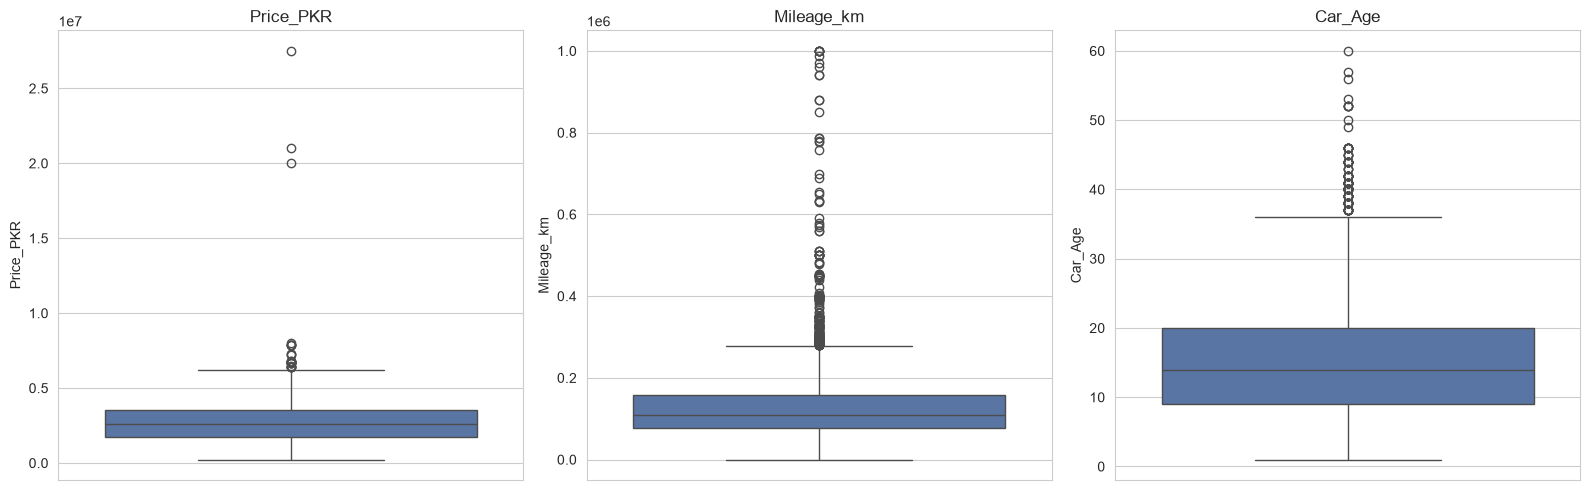

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Price_PKR', 'Mileage_km', 'Car_Age']):
    sns.boxplot(y=cars_data[col], ax=ax, color='#4C72B0')
    ax.set_title(f'{col}')
plt.tight_layout()
plt.show()

In [19]:
lower, upper = iqr_bounds(cars_data['Price_PKR'])
cars_clean = cars_data[(cars_data['Price_PKR'] >= max(lower, 0)) & (cars_data['Price_PKR'] <= upper)].copy()

# Keep Mileage capping as-is — that's a feature, not the target, so clipping there is fine
lower_m, upper_m = iqr_bounds(cars_clean['Mileage_km'])
cars_clean['Mileage_km'] = cars_clean['Mileage_km'].clip(lower=max(lower_m, 0), upper=upper_m)

cars_clean = cars_clean[(cars_clean['Year'] >= 1970) & (cars_clean['Year'] <= CURRENT_YEAR)]
print(f"Rows after outlier handling: {len(cars_clean)}")

Rows after outlier handling: 5722


In [20]:
cars_clean['Engine_cc'] = cars_clean['Engine_cc'].fillna(cars_clean['Engine_cc'].median())

---
## 11. Univariate Analysis

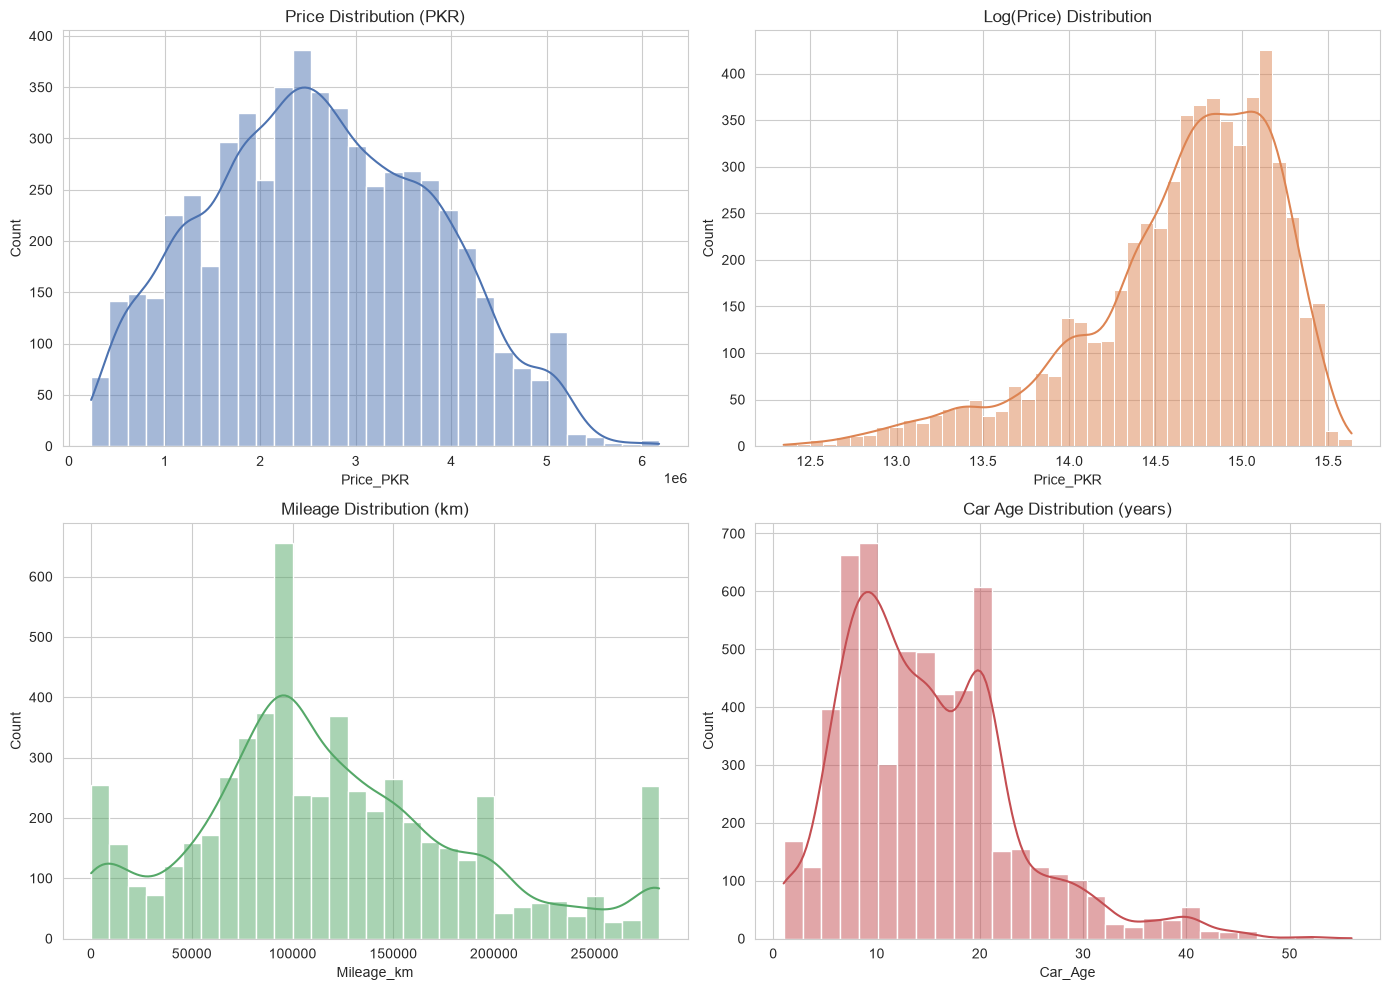

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(cars_clean['Price_PKR'], kde=True, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Price Distribution (PKR)')

sns.histplot(np.log1p(cars_clean['Price_PKR']), kde=True, ax=axes[0, 1], color='#DD8452')
axes[0, 1].set_title('Log(Price) Distribution')

sns.histplot(cars_clean['Mileage_km'], kde=True, ax=axes[1, 0], color='#55A868')
axes[1, 0].set_title('Mileage Distribution (km)')

sns.histplot(cars_clean['Car_Age'], kde=True, bins=30, ax=axes[1, 1], color='#C44E52')
axes[1, 1].set_title('Car Age Distribution (years)')

plt.tight_layout()
plt.show()

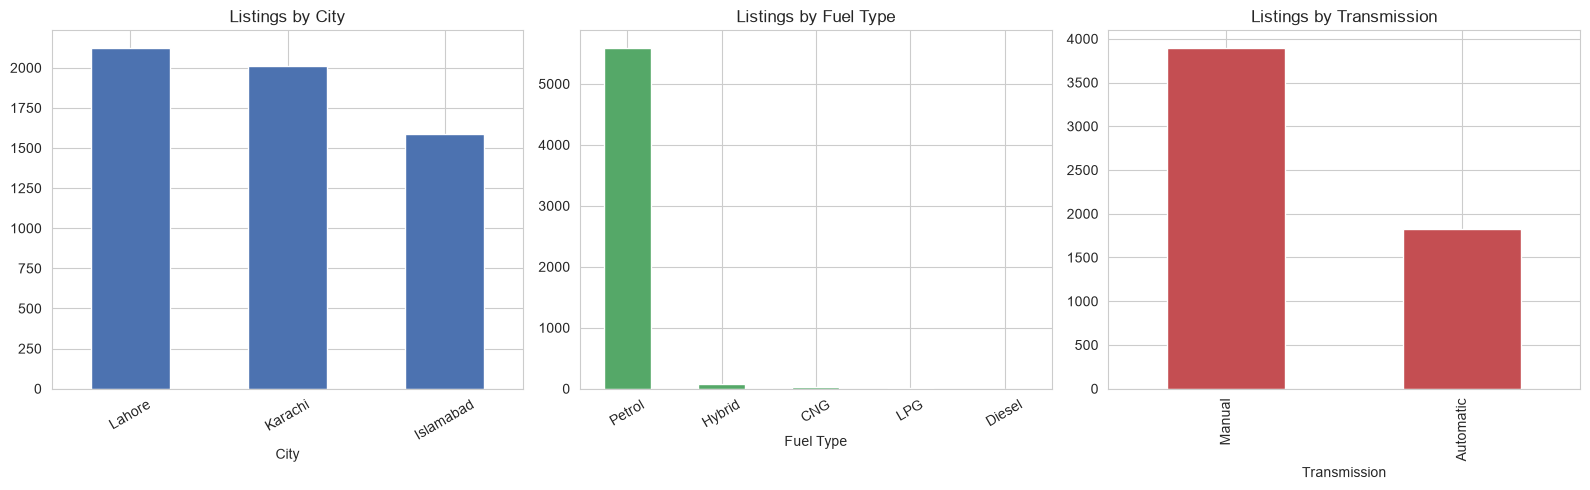

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cars_clean['City'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Listings by City')
axes[0].tick_params(axis='x', rotation=30)

cars_clean['Fuel Type'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Listings by Fuel Type')
axes[1].tick_params(axis='x', rotation=30)

cars_clean['Transmission'].value_counts().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Listings by Transmission')

plt.tight_layout()
plt.show()

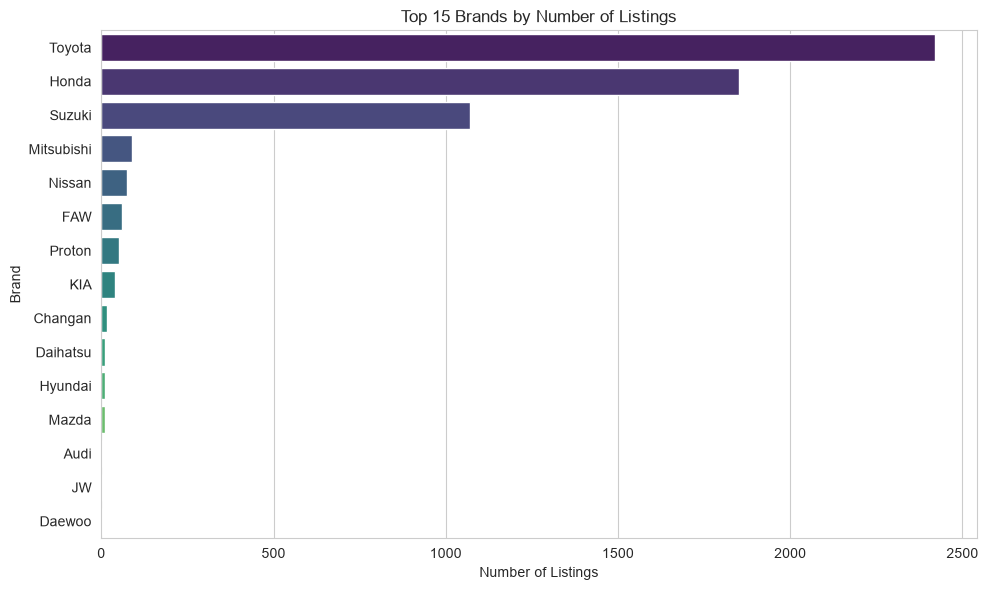

In [23]:
top_brands = cars_clean['Brand'].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette='viridis', legend=False)
plt.title('Top 15 Brands by Number of Listings')
plt.xlabel('Number of Listings')
plt.tight_layout()
plt.show()

---
## 12. Bivariate Analysis — What Drives Price?

Now let's look at `Price_PKR` against the features we plan to use for the estimator: mileage, age, brand, condition/transmission, and region (city).

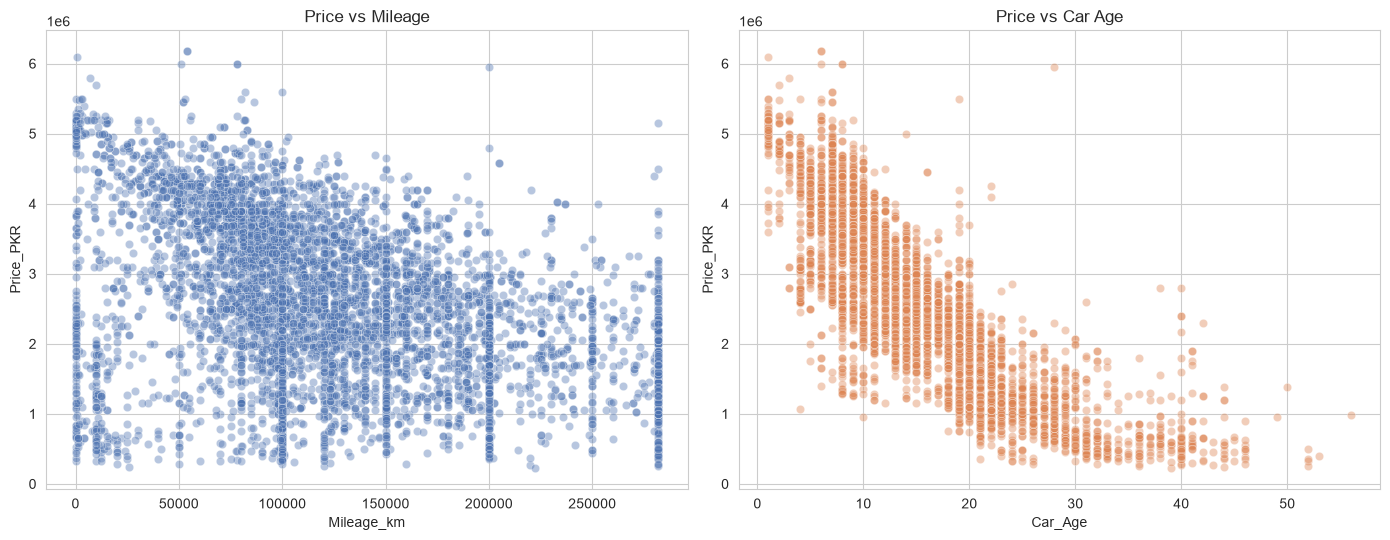

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=cars_clean, x='Mileage_km', y='Price_PKR', alpha=0.4, ax=axes[0], color='#4C72B0')
axes[0].set_title('Price vs Mileage')

sns.scatterplot(data=cars_clean, x='Car_Age', y='Price_PKR', alpha=0.4, ax=axes[1], color='#DD8452')
axes[1].set_title('Price vs Car Age')

plt.tight_layout()
plt.show()

Both plots should show a **depreciation curve** — price dropping steeply in the first few years / first tens of thousands of km, then flattening out. That non-linear shape is exactly why depreciation is usually modeled with `log(Price)` or a polynomial/tree-based model rather than plain linear regression.

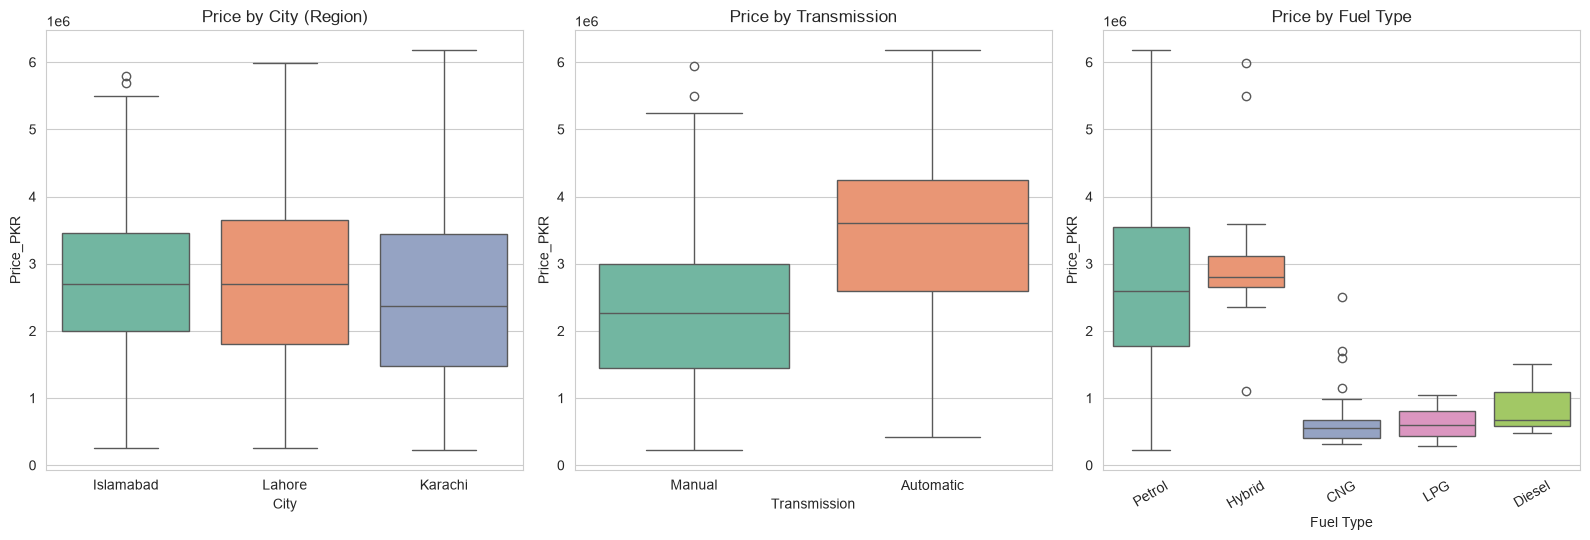

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

sns.boxplot(data=cars_clean, x='City', y='Price_PKR', hue='City', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Price by City (Region)')

sns.boxplot(data=cars_clean, x='Transmission', y='Price_PKR', hue='Transmission', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Price by Transmission')

sns.boxplot(data=cars_clean, x='Fuel Type', y='Price_PKR', hue='Fuel Type', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Price by Fuel Type')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

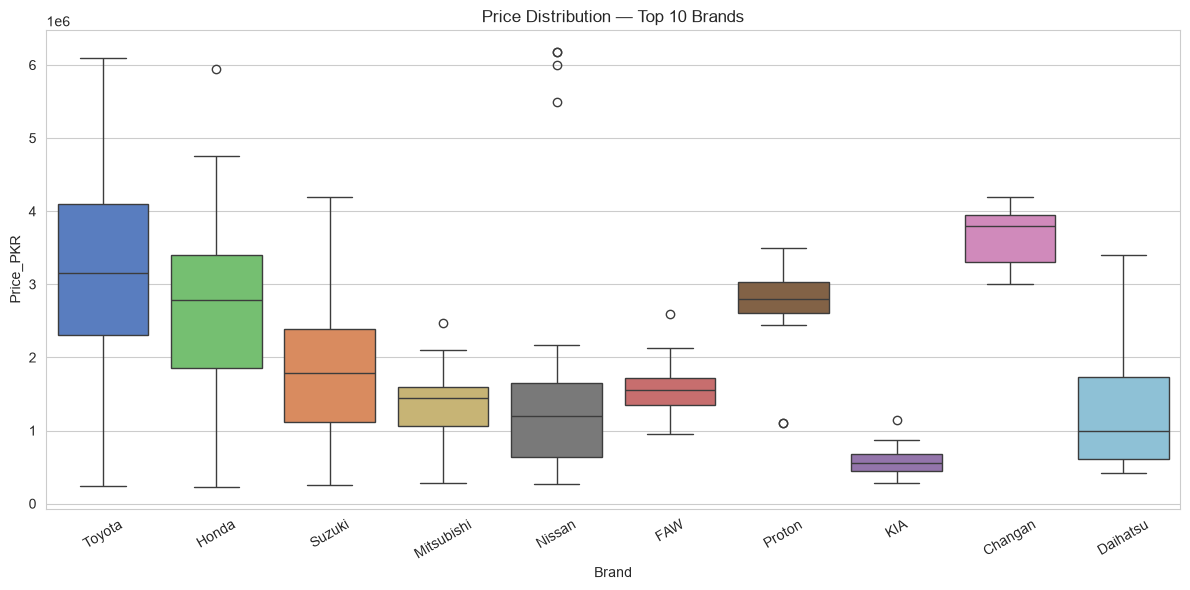

In [26]:
top10_brands = cars_clean['Brand'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=cars_clean[cars_clean['Brand'].isin(top10_brands)],
    x='Brand', y='Price_PKR', hue='Brand', palette='muted', legend=False,
    order=top10_brands,
)
plt.title('Price Distribution — Top 10 Brands')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 13. Multivariate Analysis — Correlations

A correlation heatmap of the numeric features tells us how strongly (and in what direction) each one relates to price, and whether any two features are so correlated with each other that we'd risk multicollinearity in a linear model.

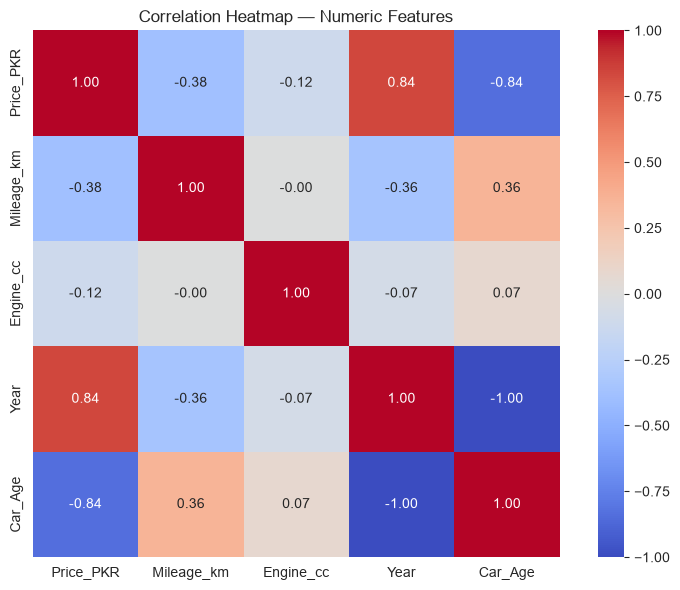

In [27]:
numeric_cols = ['Price_PKR', 'Mileage_km', 'Engine_cc', 'Year', 'Car_Age']
corr = cars_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

`Year` and `Car_Age` are mathematically the same information (`Car_Age = 2026 - Year`), so **only we only keep one of them** for modeling to avoid redundant/collinear features — `Car_Age` is usually the more intuitive one for a price estimator.

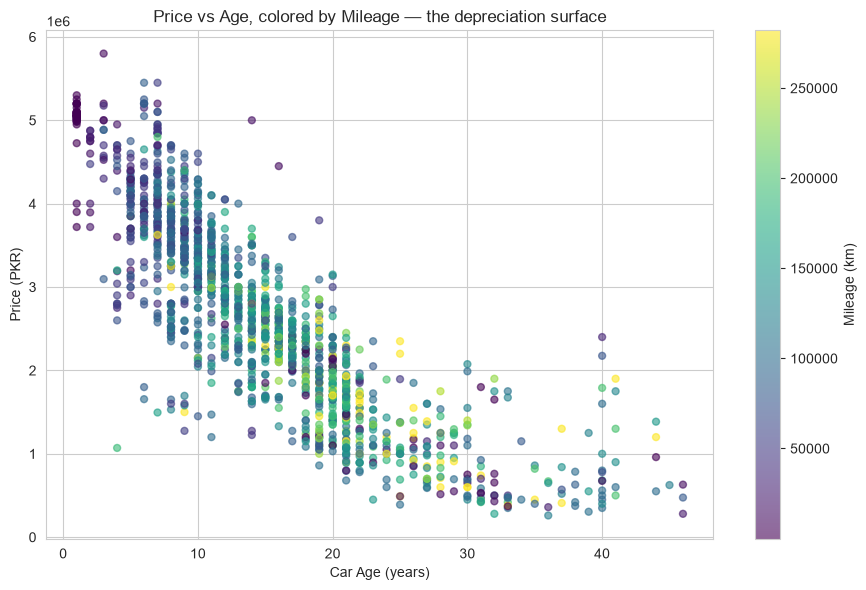

In [28]:
plt.figure(figsize=(9, 6))
sample = cars_clean.sample(min(1500, len(cars_clean)), random_state=42)  # subsample for a readable plot
scatter = plt.scatter(
    sample['Car_Age'], sample['Price_PKR'],
    c=sample['Mileage_km'], cmap='viridis', alpha=0.6, s=25
)
plt.colorbar(scatter, label='Mileage (km)')
plt.xlabel('Car Age (years)')
plt.ylabel('Price (PKR)')
plt.title('Price vs Age, colored by Mileage — the depreciation surface')
plt.tight_layout()
plt.show()

---
## 14. Groundwork for the "Fair Price" Indicator

The project calls for a fair-price flag (under/over market). A simple, explainable baseline: for each `Brand` + `Model` + `Car_Age` bucket, compute the median market price, then compare an individual listing's price against that median. We'll revisit this after modeling, but it's worth confirming now that we have enough listings per group to make the comparison meaningful.

In [29]:
group_counts = cars_clean.groupby(['Brand', 'Model'])['Price_PKR'].count().sort_values(ascending=False)
print('Top Brand-Model combinations by listing count:')
print(group_counts.head(15))
print()
print(f"Brand-Model groups with fewer than 5 listings: {(group_counts < 5).sum()} out of {len(group_counts)} groups")

Top Brand-Model combinations by listing count:
Brand       Model   
Toyota      Corolla     1848
Honda       City        1738
Suzuki      Swift        569
Toyota      Yaris        388
Suzuki      Liana        190
            Baleno       184
            Margalla     105
Mitsubishi  Lancer        90
Toyota      Vitz          87
Honda       Civic         73
Nissan      Sunny         58
FAW         V2            57
Proton      Saga          48
KIA         Classic       40
Toyota      Belta         28
Name: Price_PKR, dtype: int64

Brand-Model groups with fewer than 5 listings: 40 out of 68 groups


In [34]:
print(f"Total Brands: {cars_clean['Brand'].nunique()}")
print(f"{cars_clean['Brand'].value_counts()}")

Total Brands: 22
Brand
Toyota        2420
Honda         1851
Suzuki        1070
Mitsubishi      90
Nissan          76
FAW             60
Proton          50
KIA             41
Changan         17
Daihatsu        12
Hyundai         11
Mazda           10
Audi             2
JW               2
Daewoo           2
DFSK             2
Chevrolet        1
Datsun           1
SsangYong        1
Power            1
Lifan            1
Volkswagen       1
Name: count, dtype: int64


In [31]:
cars_clean['log_price'] = np.log1p(cars_clean['Price_PKR'])

cars_clean.to_csv(f"{PROCESSED_PATH}", index=False)
print(f"Saved Cleaned data: {cars_clean.shape}")

Saved Cleaned data: (5722, 12)


## 15. Feature Engineering Design Decision

Based on EDA findings across **5,722 cleaned listings** (from 5,772 raw · 3 cities · Jan 1966–2025 registration years), we designed **26 features across 7 groups** → 1 target (`log_price`).

| Group | Count | Features | Rationale |
|---|---|---|---|
| **Depreciation (core)** | 2 | `Car_Age`, `Mileage_km` | `Car_Age` r=**-0.84** (strongest single predictor), `Mileage_km` r=**-0.38**. Together explain most of the price-decline pattern seen in EDA scatterplots |
| **Engine** | 1 | `Engine_cc` | r=-0.12 — weak alone (98% of listings are 1300cc, low variance), but kept for interaction with Brand/Model in tree models |
| **Usage intensity (derived)** | 1 | `Mileage_per_year` | `Mileage_km / max(Car_Age,1)` — separates a lightly-driven 10-year-old car from a heavily-driven one; needed because Age and Mileage are correlated (r=0.36) and partially redundant alone |
| **Location** | 3 | `City_Lahore`, `City_Karachi`, `City_Islamabad` | One-hot, only 3 categories present in source data (Lahore = 2,146 listings, dominant) |
| **Vehicle Config** | 7 | `Fuel Type` (5 cats), `Transmission` (2 cats) — one-hot | Low cardinality, safe to one-hot directly; boxplots showed real price separation by transmission type |
| **Brand (grouped)** | 11 | Top 10 brands individually (Toyota, Honda, Suzuki, Mitsubishi, Nissan, FAW, Proton, KIA, Daihatsu, +1 more) + `Brand_Other` | Rare brands (<10 listings) bucketed to avoid sparse, unreliable dummy columns |
| **Model** | 1 | `Model_freq` (frequency-encoded) | 68 unique Brand-Model combos; 40 have <5 listings — one-hot would explode dimensionality and overfit rare combos |
| **TOTAL** | **26** | | |

**Business feature (not fed to model):**
`price_vs_group_median = Price_PKR / groupby(Brand,Model).median()` — powers the app's "fair price" flag, kept separate from training features to avoid leaking price into itself.

**Target:** `log_price = log1p(Price_PKR)` — corrects right-skew confirmed during EDA.

---

### Excluded Features

- **`Year`** — perfectly collinear with `Car_Age` (r = -1.00, since `Car_Age = 2026 - Year` by definition); including both would cause multicollinearity for zero added signal
- **`Price_PKR`** (raw) — target/output variable; including it as a feature is direct data leakage. Only `log_price` is used as target
- **`Variant`** — free-text, too sparse to encode reliably (e.g. "5th (GM2) Generation 1.3 i-VTEC"); flagged as a v2 improvement (extract keywords like "Automatic", "Navigation" as binary flags)
- **`Link`** — metadata only, already dropped during EDA cleaning

---

### Key Findings Summary

| # | Finding | Evidence |
|---|---|---|
| 1 | Dataset is clean after processing: no missing values or duplicates remain | 5,722 final rows, 0 missing, 6 exact + 16 unparseable dropped |
| 2 | `Car_Age` is overwhelmingly the strongest price driver | r = -0.84, near-linear depreciation relationship |
| 3 | `Mileage_km` adds secondary, partially-overlapping signal | r = -0.38; correlated with Age itself (r = 0.36) |
| 4 | `Engine_cc` carries almost no linear signal alone | r = -0.12 — dataset is 98% single engine size (1300cc) |
| 5 | Price distribution is right-skewed, requiring log-transform | Long tail of high-end/vintage listings confirmed in histogram |
| 6 | Geographic coverage is narrow | Only 3 cities (Lahore, Karachi, Islamabad); Lahore dominant |
| 7 | Brand/Model concentration is high | Corolla + City = ~63% of all listings; 40/68 Brand-Model groups have <5 listings |

In [1]:
import pandas as pd
df = pd.read_csv('../data/processed/cleaned_data.csv')

# Check Bolan prices
bolan = df[(df['Brand'] == 'Suzuki') & (df['Model'] == 'Bolan')]
print(bolan[['Year', 'Car_Age', 'Mileage_km', 'Price_PKR']].describe())
print("\nActual Bolan prices:")
print(bolan['Price_PKR'].sort_values())

         Year  Car_Age  Mileage_km  Price_PKR
count     1.0      1.0         1.0        1.0
mean   2005.0     21.0    170000.0   990000.0
std       NaN      NaN         NaN        NaN
min    2005.0     21.0    170000.0   990000.0
25%    2005.0     21.0    170000.0   990000.0
50%    2005.0     21.0    170000.0   990000.0
75%    2005.0     21.0    170000.0   990000.0
max    2005.0     21.0    170000.0   990000.0

Actual Bolan prices:
5049    990000.0
Name: Price_PKR, dtype: float64
